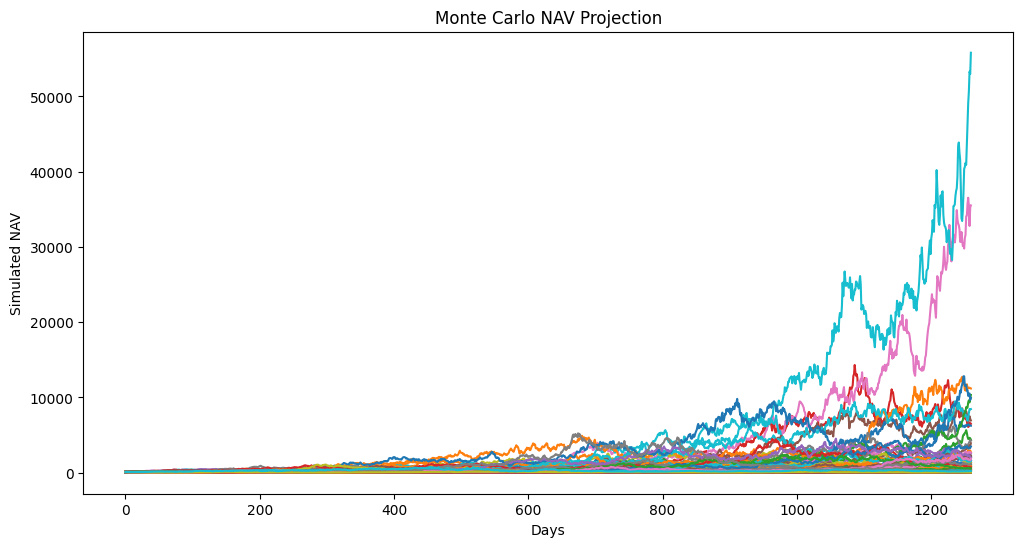

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

returns = nav["daily_return"].dropna()

mean_return = returns.mean()

volatility = returns.std()

days = 252 * 5

simulations = 100

results = np.zeros(
    (days, simulations)
)

for sim in range(simulations):

    prices = [100]

    for day in range(days):

        shock = np.random.normal(
            mean_return,
            volatility
        )

        prices.append(
            prices[-1] * (1 + shock)
        )

    results[:, sim] = prices[:-1]

plt.figure(figsize=(12,6))

plt.plot(results)

plt.title(
    "Monte Carlo NAV Projection"
)

plt.xlabel("Days")

plt.ylabel("Simulated NAV")

plt.show()

In [2]:
plt.savefig(
    "../reports/charts/monte_carlo.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>